Worksheet2

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score
from sklearn.datasets import make_classification, make_circles
from sklearn.linear_model import LogisticRegression

Softmax Function

In [ ]:
def softmax(z):

  #Compute the softmax probabilities for a given input matrix.
  # ensure 2D
    z = np.atleast_2d(z)
    z_shifted = z - np.max(z, axis=1, keepdims=True)
    exp_z = np.exp(z_shifted)
    probs = exp_z / np.sum(exp_z, axis=1, keepdims=True)
    return probs

In [ ]:
z_test = np.array([[2.0, 1.0, 0.1], [1.0, 1.0, 1.0]])
softmax_output = softmax(z_test)

row_sums = np.sum(softmax_output, axis=1)
assert np.allclose(row_sums, 1), f"Test failed: Row sums are {row_sums}"
print("Softmax function passed the test case!")
print(softmax_output)

Softmax function passed the test case!
[[0.65900114 0.24243297 0.09856589]
 [0.33333333 0.33333333 0.33333333]]


Prediction Function

In [ ]:
def predict_softmax(X, W, b):

    #Predict the class labels for a set of samples using the trained softmax model
    z = np.dot(X, W) + b
    y_pred = softmax(z)
    predicted_classes = np.argmax(y_pred, axis=1)
    return predicted_classes

In [ ]:
X_test = np.array([[0.2, 0.8], [0.5, 0.5], [0.9, 0.1]])
W_test = np.array([[0.4, 0.2, 0.1], [0.3, 0.7, 0.5]])
b_test = np.array([0.1, 0.2, 0.3])

y_pred_test = predict_softmax(X_test, W_test, b_test)

assert y_pred_test.shape == (3,), f"Test failed: Expected shape (3,), got {y_pred_test.shape}"
print("Predicted class labels:", y_pred_test)

Predicted class labels: [1 1 0]


Loss Function

In [ ]:
def loss_softmax(y_pred, y):

    #Compute the average cross-entropy loss.
    epsilon = 1e-12
    y_pred = np.clip(y_pred, epsilon, 1.0 - epsilon)
    n = y.shape[0]
    loss = -np.sum(y * np.log(y_pred)) / n
    return loss

In [ ]:
y_true_correct = np.array([[1, 0, 0], [0, 1, 0], [0, 0, 1]])

y_pred_correct = np.array([
    [0.9, 0.05, 0.05],
    [0.1, 0.85, 0.05],
    [0.05, 0.1, 0.85]
])

y_pred_incorrect = np.array([
    [0.05, 0.05, 0.9],
    [0.1, 0.05, 0.85],
    [0.85, 0.1, 0.05]
])

loss_correct = loss_softmax(y_pred_correct, y_true_correct)
loss_incorrect = loss_softmax(y_pred_incorrect, y_true_correct)

assert loss_correct < loss_incorrect, (
    f"Test failed: Expected loss_correct < loss_incorrect, but got "
    f"{loss_correct:.4f} >= {loss_incorrect:.4f}"
)

print(f"Cross-Entropy Loss (Correct Predictions): {loss_correct:.4f}")
print(f"Cross-Entropy Loss (Incorrect Predictions): {loss_incorrect:.4f}")

Cross-Entropy Loss (Correct Predictions): 0.1435
Cross-Entropy Loss (Incorrect Predictions): 2.9957


Cost Function

In [ ]:
def cost_softmax(X, y, W, b):

    #Compute the average softmax regression cost over all samples
    z = np.dot(X, W) + b
    y_pred = softmax(z)
    total_loss = loss_softmax(y_pred, y)
    return total_loss

In [ ]:
X_correct = np.array([[1.0, 0.0], [0.0, 1.0]])
y_correct = np.array([[1, 0], [0, 1]])
W_correct = np.array([[5.0, -2.0], [-3.0, 5.0]])
b_correct = np.array([0.1, 0.1])

X_incorrect = np.array([[0.1, 0.9], [0.8, 0.2]])
y_incorrect = np.array([[1, 0], [0, 1]])
W_incorrect = np.array([[0.1, 2.0], [1.5, 0.3]])
b_incorrect = np.array([0.5, 0.6])

cost_correct = cost_softmax(X_correct, y_correct, W_correct, b_correct)
cost_incorrect = cost_softmax(X_incorrect, y_incorrect, W_incorrect, b_incorrect)

assert cost_incorrect > cost_correct, (
    f"Test failed: Incorrect cost {cost_incorrect} is not greater than correct cost {cost_correct}"
)

print("Cost for correct prediction:", cost_correct)
print("Cost for incorrect prediction:", cost_incorrect)
print("Test passed!")

Cost for correct prediction: 0.0006234364133349324
Cost for incorrect prediction: 0.29930861359446115
Test passed!


Compute Gradients

In [ ]:
def compute_gradient_softmax(X, y, W, b):

    #Compute gradients of the cost function w.r.t. W and b
    n = X.shape[0]
    z = np.dot(X, W) + b
    y_pred = softmax(z)

    grad_W = np.dot(X.T, (y_pred - y)) / n
    grad_b = np.sum(y_pred - y, axis=0) / n

    return grad_W, grad_b

In [ ]:
X_test = np.array([[0.2, 0.8], [0.5, 0.5], [0.9, 0.1]])
y_test = np.array([[1, 0, 0], [0, 1, 0], [0, 0, 1]])
W_test = np.array([[0.4, 0.2, 0.1], [0.3, 0.7, 0.5]])
b_test = np.array([0.1, 0.2, 0.3])

grad_W, grad_b = compute_gradient_softmax(X_test, y_test, W_test, b_test)

z_test = np.dot(X_test, W_test) + b_test
y_pred_test = softmax(z_test)

grad_W_manual = np.dot(X_test.T, (y_pred_test - y_test)) / X_test.shape[0]
grad_b_manual = np.sum(y_pred_test - y_test, axis=0) / X_test.shape[0]

assert np.allclose(grad_W, grad_W_manual), (
    f"Test failed: Gradients w.r.t. W are not equal.\nExpected: {grad_W_manual}\nGot: {grad_W}"
)
assert np.allclose(grad_b, grad_b_manual), (
    f"Test failed: Gradients w.r.t. b are not equal.\nExpected: {grad_b_manual}\nGot: {grad_b}"
)

print("Gradient w.r.t. W:", grad_W)
print("Gradient w.r.t. b:", grad_b)
print("Test passed!")

Gradient w.r.t. W: [[ 0.1031051   0.01805685 -0.12116196]
 [-0.13600547  0.00679023  0.12921524]]
Gradient w.r.t. b: [-0.03290036  0.02484708  0.00805328]
Test passed!


Gradient Descent

In [ ]:
def gradient_descent_softmax(X, y, W, b, alpha, n_iter, show_cost=False):

    #Perform gradient descent to optimize weights and biases
    cost_history = []

    for i in range(n_iter):
        grad_W, grad_b = compute_gradient_softmax(X, y, W, b)

        W = W - alpha * grad_W
        b = b - alpha * grad_b

        cost = cost_softmax(X, y, W, b)
        cost_history.append(cost)

        if show_cost and (i % 100 == 0 or i == n_iter - 1):
            print(f"Iteration {i}: Cost = {cost:.6f}")

    return W, b, cost_history

Prepare Dataset

In [ ]:
def load_and_prepare_mnist(csv_file, test_size=0.2, random_state=42):

    # Load MNIST, normalize it, split it, and show sample digits.

    df = pd.read_csv('/content/drive/MyDrive/AI ML/Data/mnist_train.csv')

    y = df.iloc[:, 0].values
    X = df.iloc[:, 1:].values

    X = X / 255.0

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )

    plot_sample_images(X, y)

    return X_train, X_test, y_train, y_test

### Question 1 Answer

Extracting raw pixel values is a useful starting point, but it is not always sufficient for effective feature extraction.  
Pixel values only represent the intensity at each location, so they keep the image in a simple numerical form that a model can process. This works reasonably well for MNIST because the digits are small, centered, grayscale, and relatively clean.

However, raw pixels do not explicitly capture higher-level patterns such as edges, curves, stroke thickness, or shape structure. They are also sensitive to small shifts, rotation, noise, and writing style variation. Because of this, more advanced methods such as feature engineering, convolutional neural networks, or dimensionality reduction can often learn more meaningful patterns than raw pixels alone.

So, for MNIST, pixel extraction is enough to build a basic classifier, but for more complex image tasks it is usually not the most effective representation.

Train the Model

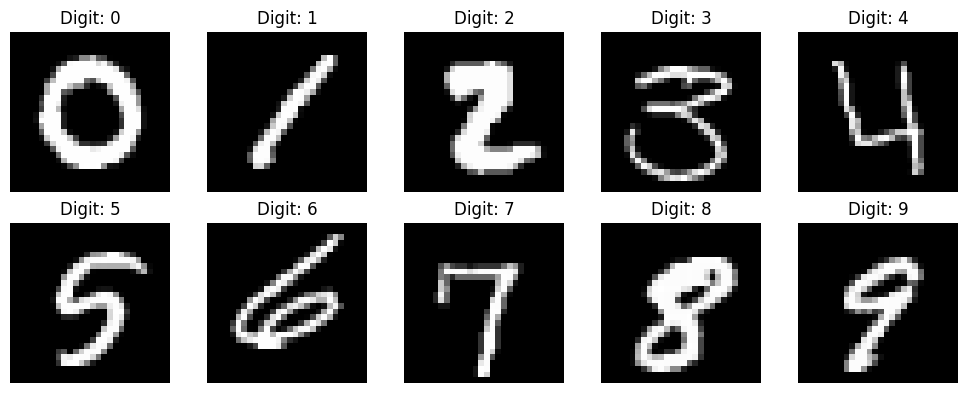

Move forward: Dimension of Feature Matrix X and label vector y matched.
Iteration 0: Cost = 2.219196
Iteration 100: Cost = 0.602324
Iteration 200: Cost = 0.483234
Iteration 300: Cost = 0.433836
Iteration 400: Cost = 0.405232
Iteration 500: Cost = 0.385987
Iteration 600: Cost = 0.371876
Iteration 700: Cost = 0.360935
Iteration 800: Cost = 0.352116
Iteration 900: Cost = 0.344798
Iteration 999: Cost = 0.338648


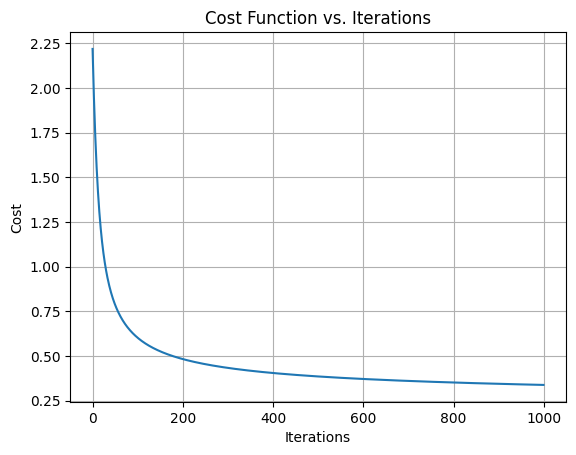

In [ ]:
#Load the dataset
csv_file = "/content/drive/MyDrive/AI ML/Data/mnist_train.csv"

X_train, X_test, y_train, y_test = load_and_prepare_mnist(csv_file)

assert len(X_train) == len(y_train), (
    f"Error: X and y have different lengths! X={len(X_train)}, y={len(y_train)}"
)
print("Move forward: Dimension of Feature Matrix X and label vector y matched.")

# One-hot encode labels
if len(y_train.shape) == 1:
    encoder = OneHotEncoder(sparse_output=False)
    y_train = encoder.fit_transform(y_train.reshape(-1, 1))
    y_test = encoder.transform(y_test.reshape(-1, 1))

d = X_train.shape[1]
c = y_train.shape[1]

np.random.seed(42)
W = np.random.randn(d, c) * 0.01
b = np.zeros(c)

alpha = 0.1
n_iter = 1000

W_opt, b_opt, cost_history = gradient_descent_softmax(
    X_train, y_train, W, b, alpha, n_iter, show_cost=True
)

plt.plot(cost_history)
plt.title('Cost Function vs. Iterations')
plt.xlabel('Iterations')
plt.ylabel('Cost')
plt.grid(True)
plt.show()

Evaluating the Model

In [ ]:
def evaluate_classification(y_true, y_pred):
    #Evaluate classification performance using confusion matrix, precision, recall, and F1-score

    cm = confusion_matrix(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted')
    recall = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')
    return cm, precision, recall, f1

In [ ]:
y_pred_test = predict_softmax(X_test, W_opt, b_opt)
y_test_labels = np.argmax(y_test, axis=1)

cm, precision, recall, f1 = evaluate_classification(y_test_labels, y_pred_test)

print("\nConfusion Matrix:")
print(cm)
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")


Confusion Matrix:
[[795   0   3   4   2   6  10   0   5   2]
 [  0 908   2   6   0   6   3   3   8   1]
 [  6   5 738  13  18   4   9  18  20   4]
 [  5   5  28 756   2  36   6   7  16   9]
 [  2   5   8   1 741   1   7   3   6  40]
 [ 12  10   9  33  19 619  10   7  28  12]
 [  5   5   6   1   6  13 783   0   7   1]
 [  1   8  12   5  12   0   1 803   4  34]
 [  5  22   7  21   4  28   7   4 694  21]
 [  5   5   6  11  36   5   1  31   5 733]]
Precision: 0.9008
Recall: 0.9012
F1-Score: 0.9009


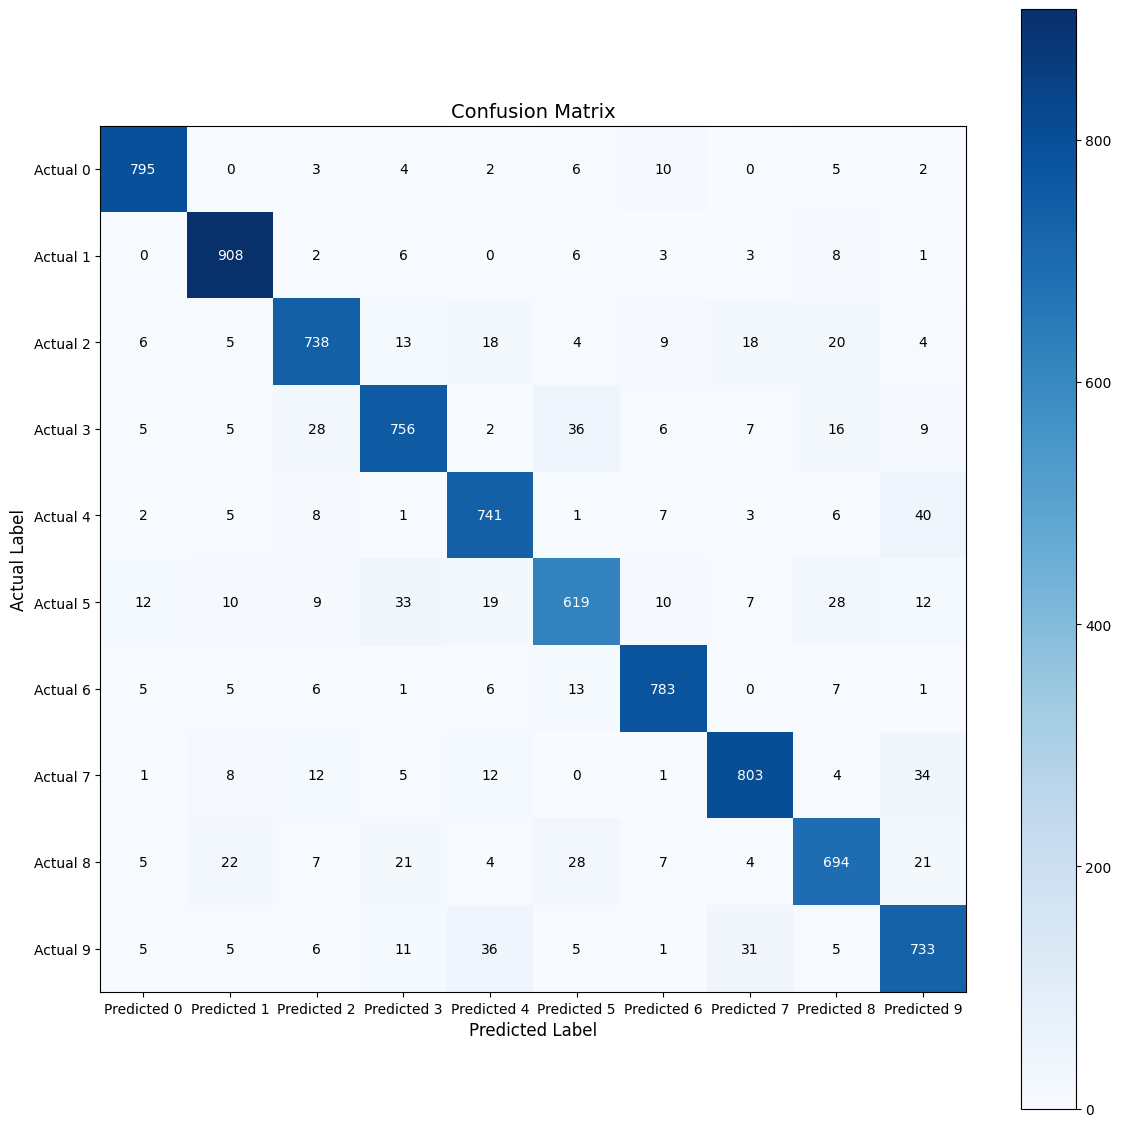

In [ ]:
fig, ax = plt.subplots(figsize=(12, 12))
cax = ax.imshow(cm, cmap='Blues')

num_classes = cm.shape[0]
ax.set_xticks(range(num_classes))
ax.set_yticks(range(num_classes))
ax.set_xticklabels([f'Predicted {i}' for i in range(num_classes)])
ax.set_yticklabels([f'Actual {i}' for i in range(num_classes)])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(
            j, i, cm[i, j],
            ha='center', va='center',
            color='white' if cm[i, j] > np.max(cm) / 2 else 'black'
        )

ax.grid(False)
plt.title('Confusion Matrix', fontsize=14)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('Actual Label', fontsize=12)
plt.tight_layout()
plt.colorbar(cax)
plt.show()

Linear separability and logistic regression

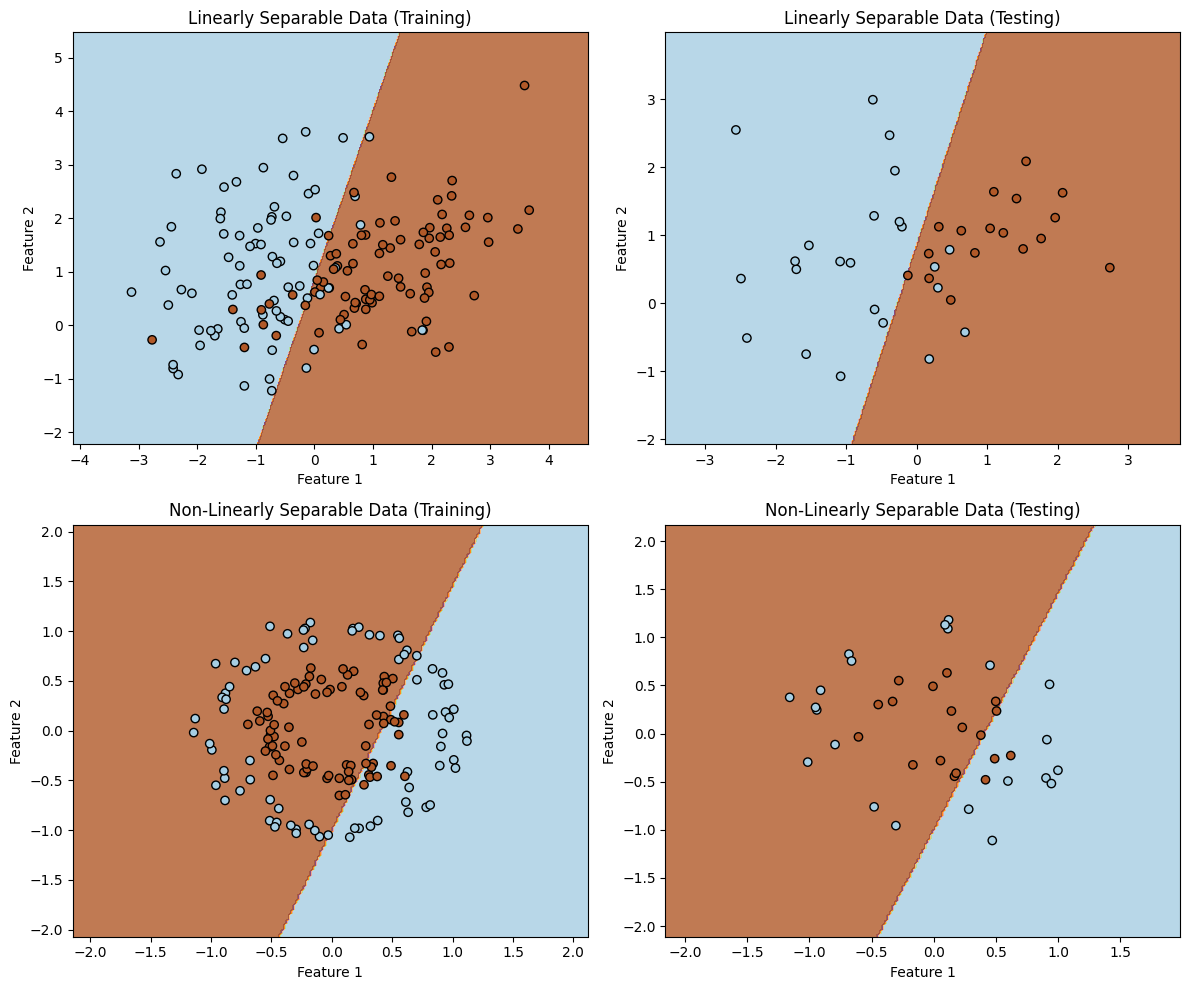

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification, make_circles
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

np.random.seed(42)

# Generate linearly separable dataset
X_linear_separable, y_linear_separable = make_classification(
    n_samples=200,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_clusters_per_class=1,
    random_state=42
)

X_train_linear, X_test_linear, y_train_linear, y_test_linear = train_test_split(
    X_linear_separable, y_linear_separable, test_size=0.2, random_state=42
)

logistic_model_linear_separable = LogisticRegression()
logistic_model_linear_separable.fit(X_train_linear, y_train_linear)

# Generate non-linearly separable dataset
X_non_linear_separable, y_non_linear_separable = make_circles(
    n_samples=200,
    noise=0.1,
    factor=0.5,
    random_state=42
)

X_train_non_linear, X_test_non_linear, y_train_non_linear, y_test_non_linear = train_test_split(
    X_non_linear_separable, y_non_linear_separable, test_size=0.2, random_state=42
)

logistic_model_non_linear_separable = LogisticRegression()
logistic_model_non_linear_separable.fit(X_train_non_linear, y_train_non_linear)

def plot_decision_boundary(ax, model, X, y, title):
    h = 0.02
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, h),
        np.arange(y_min, y_max, h)
    )

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.Paired)
    ax.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap=plt.cm.Paired)

    ax.set_title(title)
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

plot_decision_boundary(
    axes[0, 0],
    logistic_model_linear_separable,
    X_train_linear,
    y_train_linear,
    'Linearly Separable Data (Training)'
)

plot_decision_boundary(
    axes[0, 1],
    logistic_model_linear_separable,
    X_test_linear,
    y_test_linear,
    'Linearly Separable Data (Testing)'
)

plot_decision_boundary(
    axes[1, 0],
    logistic_model_non_linear_separable,
    X_train_non_linear,
    y_train_non_linear,
    'Non-Linearly Separable Data (Training)'
)

plot_decision_boundary(
    axes[1, 1],
    logistic_model_non_linear_separable,
    X_test_non_linear,
    y_test_non_linear,
    'Non-Linearly Separable Data (Testing)'
)

plt.tight_layout()
plt.savefig('decision_boundaries.png')
plt.show()

### Question 2 Answer

The plots show that logistic regression works much better on linearly separable data than on non-linearly separable data.

For the linearly separable dataset, the decision boundary divides the classes fairly well in both the training and testing plots. This means logistic regression can learn a good separating line because the two classes can be separated using a linear boundary.

For the non-linearly separable circular dataset, the model struggles because logistic regression still tries to fit a straight-line boundary. Since the true pattern is curved, many points are placed in the wrong region. This shows an important limitation of basic logistic regression: it performs well when the relationship is approximately linear, but it is not suitable by itself for strongly non-linear patterns unless we add transformed features or use a more flexible model.


### Question 3 Answer

One of the main challenges was making sure the data dimensions matched correctly during matrix operations, especially for the feature matrix, weight matrix, bias vector, and one-hot encoded labels. Another challenge was implementing softmax in a numerically stable way, because taking exponentials directly can lead to overflow errors. It was also important to ensure that the loss decreased during gradient descent, which required choosing a reasonable learning rate and checking the formulas carefully. For the decision boundary plots, the main difficulty was understanding how the mesh grid is created and how the model predictions are reshaped back into the plotting area.